## 1. problem defination :
predictiong total price for international  study fee  based on department,place ,university etc..

In [293]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [294]:
#pip install scikit-learn

In [295]:
df=pd.read_csv("/Users/ramireddyvishnuvardhanreddy/Desktop/tutede/MachineLearning/International_Education_Costs.csv")
df

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92
...,...,...,...,...,...,...,...,...,...,...,...,...
902,France,Strasbourg,University of Strasbourg,Data Analytics,Master,2.0,4000,70.2,1000,99,850,0.92
903,Malaysia,Nilai,USIM,Computer Science,Bachelor,3.0,6800,50.5,400,120,400,4.65
904,Saudi Arabia,Al-Ahsa,King Faisal University,Information Systems,Master,2.0,4200,64.2,600,200,800,3.75
905,USA,Seattle,University of Washington,Software Development,PhD,5.0,50000,77.8,2000,160,1500,1.00


In [296]:
df.describe() #display statistical information about data

,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,2.836825,16705.016538,64.437486,969.206174,211.396913,700.077178,623.000695
std,0.945449,16582.385275,14.056333,517.154752,143.435740,320.374875,3801.746134
min,1.000000,0.000000,27.800000,150.000000,40.000000,200.000000,0.150000
25%,2.000000,2850.000000,56.300000,545.000000,100.000000,450.000000,0.920000
50%,3.000000,7500.000000,67.500000,900.000000,160.000000,650.000000,1.350000
75%,4.000000,31100.000000,72.200000,1300.000000,240.000000,800.000000,7.150000
max,5.000000,62000.000000,122.400000,2500.000000,490.000000,1500.000000,42150.000000


In [297]:
df.info() #display information like no of rows ,columns,data type of each column name ,memory usage,not null count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    object 
 1   City               907 non-null    object 
 2   University         907 non-null    object 
 3   Program            907 non-null    object 
 4   Level              907 non-null    object 
 5   Duration_Years     907 non-null    float64
 6   Tuition_USD        907 non-null    int64  
 7   Living_Cost_Index  907 non-null    float64
 8   Rent_USD           907 non-null    int64  
 9   Visa_Fee_USD       907 non-null    int64  
 10  Insurance_USD      907 non-null    int64  
 11  Exchange_Rate      907 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 85.2+ KB


In [298]:
df.shape #used to count numner of columns and rowns in dataset

(907, 12)

In [299]:
df.size #return total number of elements in dataset (rows*columns)

10884

In [300]:
df.dtypes #return data type of each column in dataset

Country               object
City                  object
University            object
Program               object
Level                 object
Duration_Years       float64
Tuition_USD            int64
Living_Cost_Index    float64
Rent_USD               int64
Visa_Fee_USD           int64
Insurance_USD          int64
Exchange_Rate        float64
dtype: object

In [301]:
df['Country'].value_counts()#it count frequency of each unique value

Country
UK                93
Australia         86
USA               78
Canada            76
Germany           33
                  ..
Nigeria            1
Israel             1
Taiwan             1
South Africa       1
Czech Republic     1
Name: count, Length: 71, dtype: int64

In [302]:
#df.unique() #it should be used for one column at a time

In [303]:
df['Country'].unique() #return all unique values

array(['USA', 'UK', 'Canada', 'Australia', 'Germany', 'Japan',
       'Netherlands', 'Singapore', 'France', 'Switzerland', 'Sweden',
       'Denmark', 'China', 'South Korea', 'Ireland', 'New Zealand',
       'Austria', 'Belgium', 'Hong Kong', 'Portugal', 'Israel', 'Taiwan',
       'Czech Republic', 'India', 'Poland', 'Malaysia', 'Spain', 'Italy',
       'Finland', 'Norway', 'Brazil', 'Turkey', 'Russia', 'Mexico',
       'Greece', 'Thailand', 'UAE', 'South Africa', 'Egypt', 'Argentina',
       'Indonesia', 'Saudi Arabia', 'Nigeria', 'Vietnam', 'Hungary',
       'Iceland', 'Colombia', 'Romania', 'Luxembourg', 'Tunisia',
       'Cyprus', 'Croatia', 'Dominican Republic', 'Morocco', 'Peru',
       'Ecuador', 'Lebanon', 'Bahrain', 'Uruguay', 'Bulgaria', 'Ghana',
       'Algeria', 'Panama', 'Bangladesh', 'Kuwait', 'Ukraine', 'Slovenia',
       'Serbia', 'Iran', 'Uzbekistan', 'El Salvador'], dtype=object)

In [304]:
df[df['Country']== "India"] # here finding how  many are of them india

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
44,India,Bangalore,Indian Institute of Science,Computer Science,Master,2.0,2500,45.6,500,200,300,83.20
648,India,Bangalore,Indian Institute of Science,Data Science,PhD,4.0,2000,45.2,300,180,300,82.75
654,India,Mumbai,IIT Bombay,Computer Engineering,Master,2.0,1800,47.5,350,180,300,82.75
659,India,Delhi,IIT Delhi,Artificial Intelligence,PhD,4.0,1900,44.8,320,180,300,82.75
665,India,Chennai,IIT Madras,Software Engineering,Master,2.0,1700,42.4,280,180,300,82.75
671,India,Hyderabad,IIT Hyderabad,Data Analytics,PhD,4.0,1800,41.2,260,180,300,82.75
677,India,Pune,IIT Pune,Computer Science,Master,2.0,1600,40.5,250,180,300,82.75
683,India,Kanpur,IIT Kanpur,Artificial Intelligence,PhD,4.0,1900,39.8,240,180,300,82.75


In [305]:
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='object')

In [306]:
df['Level'].value_counts()

Level
Master      451
Bachelor    297
PhD         159
Name: count, dtype: int64

In [307]:
df['Duration_Years'].value_counts()

Duration_Years
2.0    423
4.0    276
3.0    171
5.0     17
1.0     16
2.5      3
1.5      1
Name: count, dtype: int64

In [308]:
df['Duration_Years'].max()

5.0

In [309]:
df['Duration_Years'].mean()

2.8368246968026463

In [310]:
##isnull() is used to check whether values are missing or not
#it returns True if values are missing and False if values are not missing

In [311]:
df.isnull()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
902,False,False,False,False,False,False,False,False,False,False,False,False
903,False,False,False,False,False,False,False,False,False,False,False,False
904,False,False,False,False,False,False,False,False,False,False,False,False
905,False,False,False,False,False,False,False,False,False,False,False,False


In [312]:
df.isnull().sum()#no missing values are present in dataset 

Country              0
City                 0
University           0
Program              0
Level                0
Duration_Years       0
Tuition_USD          0
Living_Cost_Index    0
Rent_USD             0
Visa_Fee_USD         0
Insurance_USD        0
Exchange_Rate        0
dtype: int64

In [313]:
df.duplicated() #if any duplicates values are present it returns true else false

0      False
1      False
2      False
3      False
4      False
       ...  
902    False
903    False
904    False
905    False
906    False
Length: 907, dtype: bool

In [314]:
df.dtypes #return data type of each column in dataset

Country               object
City                  object
University            object
Program               object
Level                 object
Duration_Years       float64
Tuition_USD            int64
Living_Cost_Index    float64
Rent_USD               int64
Visa_Fee_USD           int64
Insurance_USD          int64
Exchange_Rate        float64
dtype: object

In [315]:
df['Duration_Years']=df['Duration_Years'].astype('float32')#changing data type of column

In [316]:
df['Living_Cost_Index']=df['Living_Cost_Index'].astype('float32')
df['Tuition_USD']=df['Tuition_USD'].astype('int32')
df['Rent_USD']=df['Rent_USD'].astype('int32')
df['Exchange_Rate']=df['Exchange_Rate'].astype('float32')
df['Visa_Fee_USD']=df['Visa_Fee_USD'].astype('int32')

In [317]:
df.info()
#above when comparing with previous info() we can see that memory usage decreased from 81 to 63.9 gb

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    object 
 1   City               907 non-null    object 
 2   University         907 non-null    object 
 3   Program            907 non-null    object 
 4   Level              907 non-null    object 
 5   Duration_Years     907 non-null    float32
 6   Tuition_USD        907 non-null    int32  
 7   Living_Cost_Index  907 non-null    float32
 8   Rent_USD           907 non-null    int32  
 9   Visa_Fee_USD       907 non-null    int32  
 10  Insurance_USD      907 non-null    int64  
 11  Exchange_Rate      907 non-null    float32
dtypes: float32(3), int32(3), int64(1), object(5)
memory usage: 63.9+ KB


# Exploratory Data Analysis

In [318]:
# exploratory Data Analysis(EDA)
# we need to find relation between columns with target values


In [319]:
## univarite analysis

In [320]:
df['Country'].value_counts() #i am intrested in top 10 countries not all

Country
UK                93
Australia         86
USA               78
Canada            76
Germany           33
                  ..
Nigeria            1
Israel             1
Taiwan             1
South Africa       1
Czech Republic     1
Name: count, Length: 71, dtype: int64

In [321]:
country=df[df['Country'].isin(['UK','USA','Australia','Canada','Germany','France','Japan','China','India','Russia'])]

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'USA'),
  Text(1, 0, 'UK'),
  Text(2, 0, 'Canada'),
  Text(3, 0, 'Australia'),
  Text(4, 0, 'Germany'),
  Text(5, 0, 'Japan'),
  Text(6, 0, 'France'),
  Text(7, 0, 'China'),
  Text(8, 0, 'India'),
  Text(9, 0, 'Russia')])

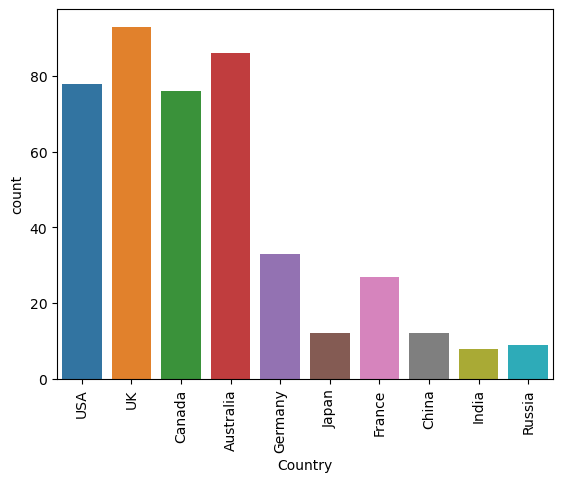

In [322]:
sns.countplot(x='Country',data=country)
plt.xticks(rotation=90) #without xticks the country names are overlapping so xticks are used

In [323]:
df['City'].value_counts().head(10)

City
Singapore    18
Melbourne    11
Sydney       11
London       10
Canberra      8
Brisbane      7
Newcastle     7
Seoul         6
Cambridge     6
Seattle       6
Name: count, dtype: int64

In [324]:
city=df[df['City'].isin(['Singapore','Melbourne','Sydney','London','Canberra','Brisbane','Newcastle','Seattle'])]

<Axes: xlabel='Country', ylabel='count'>

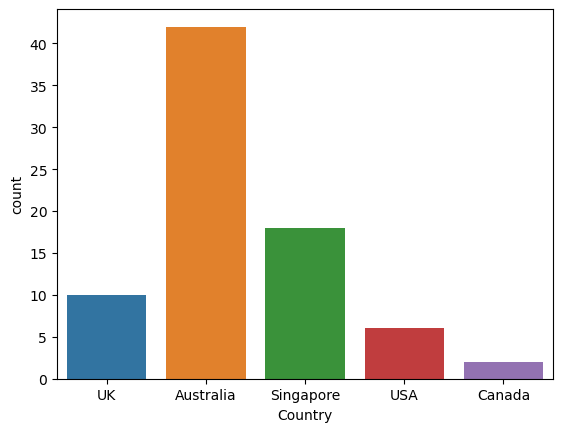

In [325]:
sns.countplot(x='Country',data=city)

In [326]:
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='object')

In [327]:
d1=df[df['Level']=="Bachelor"].head(50)

In [328]:
d2=df[df['Level']=="Master"].head(50)

In [329]:
d3=df[df['Level']=="PhD"].head(50)

In [330]:
d4=pd.concat([d1,d2,d3])

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Duration_Years', ylabel='Count'>

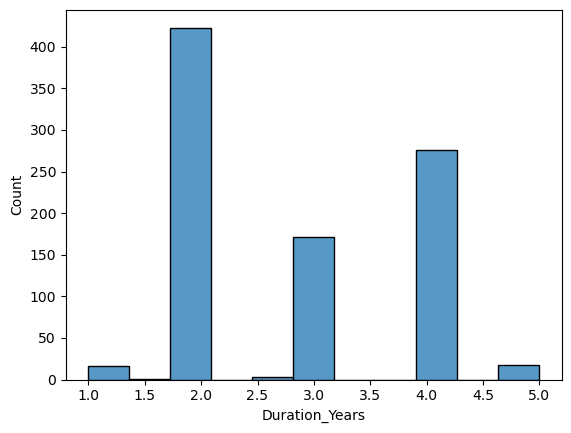

In [331]:
sns.histplot(data=df,x='Duration_Years',)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Duration_Years', ylabel='Count'>

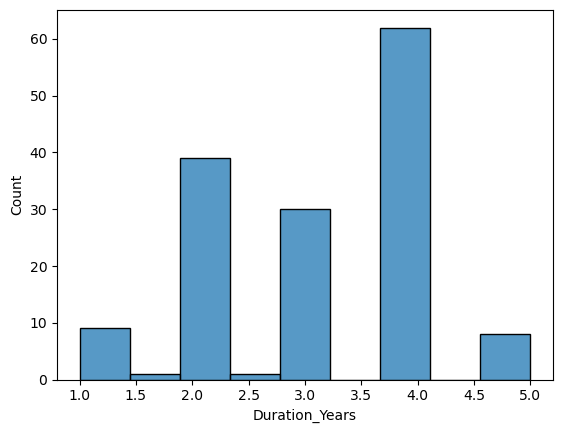

In [332]:
sns.histplot(x='Duration_Years',data=d4)

In [333]:
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='object')

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Rent_USD', ylabel='Count'>

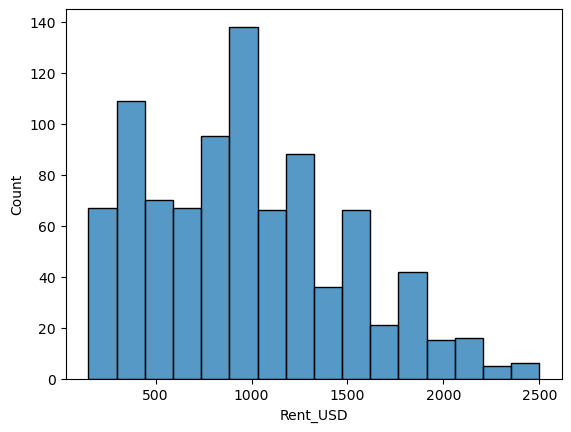

In [334]:
sns.histplot(x='Rent_USD',data=df)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Rent_USD', ylabel='Density'>

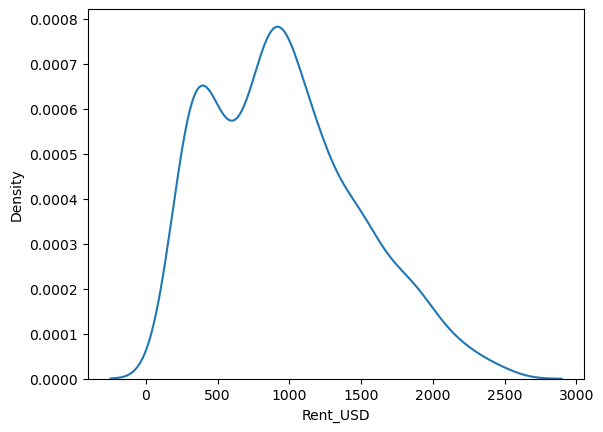

In [335]:
sns.kdeplot(data=df,x='Rent_USD')

<Axes: xlabel='Rent_USD'>

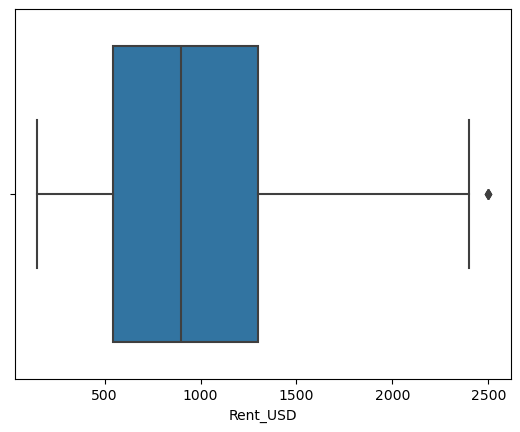

In [336]:
sns.boxplot(data=df,x='Rent_USD',)

In [337]:
#Bivariate analysys
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    object 
 1   City               907 non-null    object 
 2   University         907 non-null    object 
 3   Program            907 non-null    object 
 4   Level              907 non-null    object 
 5   Duration_Years     907 non-null    float32
 6   Tuition_USD        907 non-null    int32  
 7   Living_Cost_Index  907 non-null    float32
 8   Rent_USD           907 non-null    int32  
 9   Visa_Fee_USD       907 non-null    int32  
 10  Insurance_USD      907 non-null    int64  
 11  Exchange_Rate      907 non-null    float32
dtypes: float32(3), int32(3), int64(1), object(5)
memory usage: 63.9+ KB


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'USA'),
  Text(1, 0, 'UK'),
  Text(2, 0, 'Canada'),
  Text(3, 0, 'Australia'),
  Text(4, 0, 'Germany'),
  Text(5, 0, 'Japan'),
  Text(6, 0, 'France'),
  Text(7, 0, 'China'),
  Text(8, 0, 'India'),
  Text(9, 0, 'Russia')])

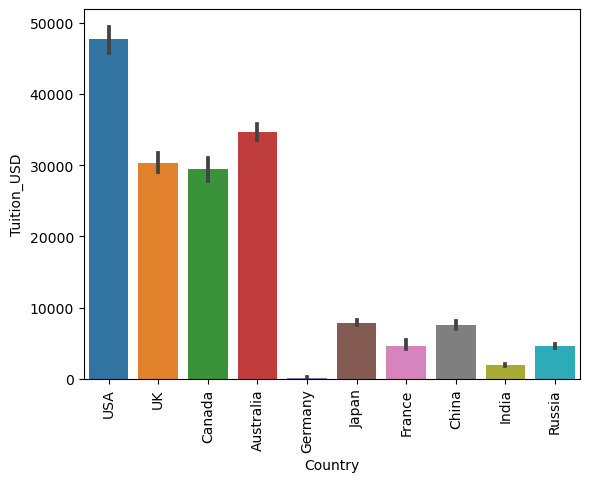

In [338]:
sns.barplot(x='Country',y="Tuition_USD",data=country)
plt.xticks(rotation=90)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'USA'),
  Text(1, 0, 'UK'),
  Text(2, 0, 'Canada'),
  Text(3, 0, 'Australia'),
  Text(4, 0, 'Germany'),
  Text(5, 0, 'Japan'),
  Text(6, 0, 'France'),
  Text(7, 0, 'China'),
  Text(8, 0, 'India'),
  Text(9, 0, 'Russia')])

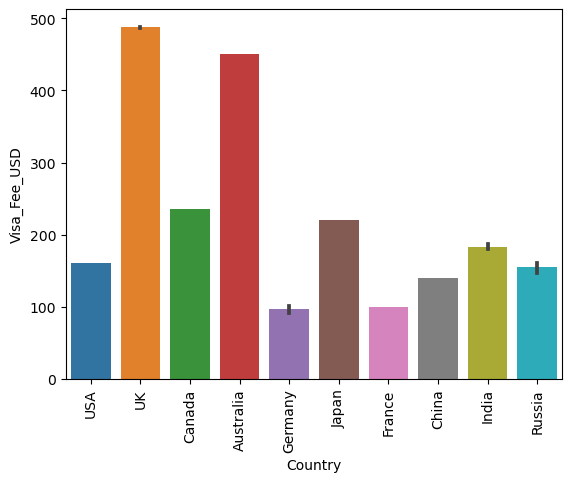

In [339]:
sns.barplot(data=country,x='Country',y="Visa_Fee_USD")
plt.xticks(rotation=90)

In [340]:
df['University'].value_counts().head(10)

University
University of Washington           6
University of Sydney               5
University of Tasmania             5
University of Wollongong           5
Australian National University     5
Griffith University                5
Stanford University                5
University of Western Australia    5
University of Adelaide             5
University of Newcastle            5
Name: count, dtype: int64

In [341]:
University=df[df['University'].isin(['University','University of Washington'  ,'University of Sydney' ,'University of Tasmania','University of Wollongong','Australian National University','Griffith University','Stanford University','University of Western Australia','University of Adelaide','University of Newcastle'])]
University

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
29,USA,Stanford,Stanford University,Computer Science,PhD,5.0,54200,89.500000,2300,160,1500,1.00
38,Australia,Canberra,Australian National University,Climate Science,PhD,4.0,29800,70.199997,1400,450,650,1.52
41,USA,Seattle,University of Washington,Computer Science,Master,2.0,38900,83.400002,2000,160,1500,1.00
53,Australia,Sydney,University of Sydney,Business,Bachelor,3.0,35000,72.800003,1600,450,650,1.52
71,Australia,Adelaide,University of Adelaide,Computer Science,Bachelor,3.0,32800,68.500000,1100,450,650,1.52
72,Australia,Perth,University of Western Australia,Software Engineering,Master,2.0,34500,69.800003,1200,450,650,1.52
73,Australia,Gold Coast,Griffith University,Information Technology,Bachelor,3.0,31200,67.500000,1100,450,650,1.52
74,Australia,Hobart,University of Tasmania,Data Science,Master,2.0,30800,65.400002,950,450,650,1.52
75,Australia,Newcastle,University of Newcastle,Computer Engineering,Bachelor,4.0,31500,66.800003,1000,450,650,1.52
76,Australia,Wollongong,University of Wollongong,Artificial Intelligence,Master,2.0,32900,67.199997,1050,450,650,1.52


In [342]:
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='object')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Stanford University'),
  Text(1, 0, 'Australian National University'),
  Text(2, 0, 'University of Washington'),
  Text(3, 0, 'University of Sydney'),
  Text(4, 0, 'University of Adelaide'),
  Text(5, 0, 'University of Western Australia'),
  Text(6, 0, 'Griffith University'),
  Text(7, 0, 'University of Tasmania'),
  Text(8, 0, 'University of Newcastle'),
  Text(9, 0, 'University of Wollongong')])

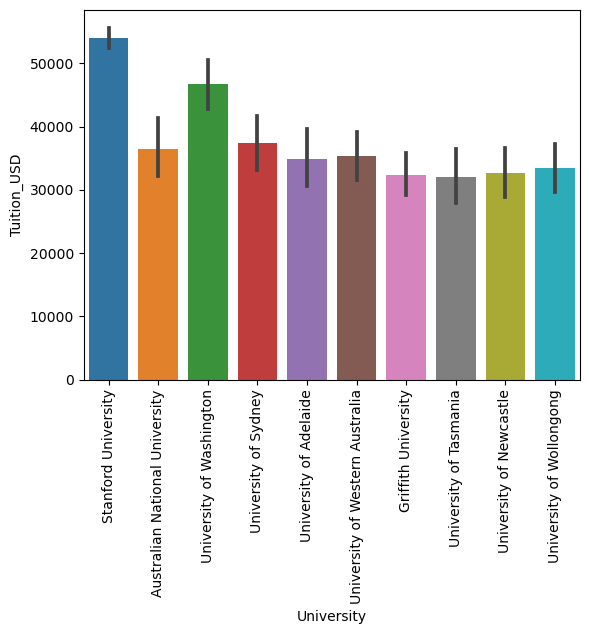

In [343]:
sns.barplot(x='University',y="Tuition_USD",data=University)
plt.xticks(rotation='vertical')

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Stanford University'),
  Text(1, 0, 'Australian National University'),
  Text(2, 0, 'University of Washington'),
  Text(3, 0, 'University of Sydney'),
  Text(4, 0, 'University of Adelaide'),
  Text(5, 0, 'University of Western Australia'),
  Text(6, 0, 'Griffith University'),
  Text(7, 0, 'University of Tasmania'),
  Text(8, 0, 'University of Newcastle'),
  Text(9, 0, 'University of Wollongong')])

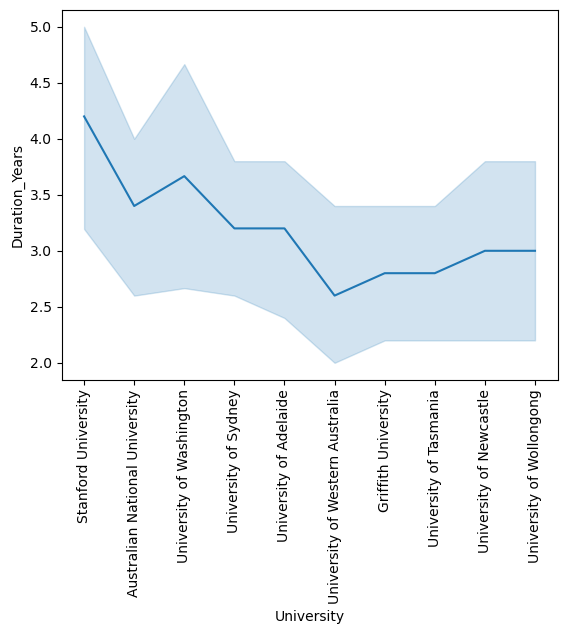

In [344]:
sns.lineplot(x='University',y='Duration_Years',data=University)
plt.xticks(rotation='vertical')

<Axes: xlabel='Duration_Years', ylabel='Tuition_USD'>

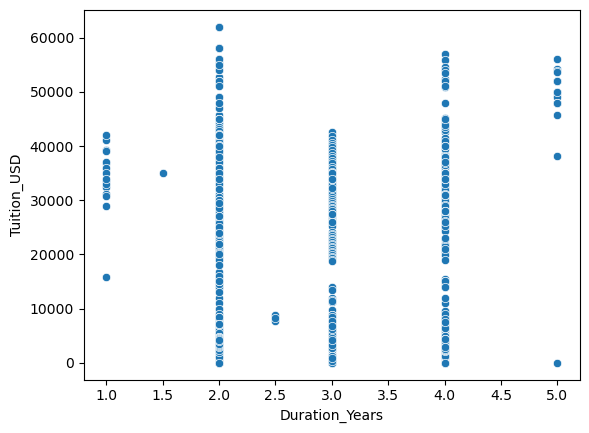

In [345]:
sns.scatterplot(data=df,x='Duration_Years',y='Tuition_USD')

In [346]:
country['Country'].value_counts()

Country
UK           93
Australia    86
USA          78
Canada       76
Germany      33
France       27
Japan        12
China        12
Russia        9
India         8
Name: count, dtype: int64

In [347]:
University['University'].value_counts().head(10)

University
University of Washington           6
Stanford University                5
Australian National University     5
University of Sydney               5
University of Adelaide             5
University of Western Australia    5
Griffith University                5
University of Tasmania             5
University of Newcastle            5
University of Wollongong           5
Name: count, dtype: int64

In [348]:
University=country[country['University'].isin(['University','University of Washington'  ,'University of Sydney' ,'University of Tasmania','University of Wollongong','Australian National University','Griffith University','Stanford University','University of Western Australia','University of Adelaide','University of Newcastle'])]
University

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
29,USA,Stanford,Stanford University,Computer Science,PhD,5.0,54200,89.500000,2300,160,1500,1.00
38,Australia,Canberra,Australian National University,Climate Science,PhD,4.0,29800,70.199997,1400,450,650,1.52
41,USA,Seattle,University of Washington,Computer Science,Master,2.0,38900,83.400002,2000,160,1500,1.00
53,Australia,Sydney,University of Sydney,Business,Bachelor,3.0,35000,72.800003,1600,450,650,1.52
71,Australia,Adelaide,University of Adelaide,Computer Science,Bachelor,3.0,32800,68.500000,1100,450,650,1.52
72,Australia,Perth,University of Western Australia,Software Engineering,Master,2.0,34500,69.800003,1200,450,650,1.52
73,Australia,Gold Coast,Griffith University,Information Technology,Bachelor,3.0,31200,67.500000,1100,450,650,1.52
74,Australia,Hobart,University of Tasmania,Data Science,Master,2.0,30800,65.400002,950,450,650,1.52
75,Australia,Newcastle,University of Newcastle,Computer Engineering,Bachelor,4.0,31500,66.800003,1000,450,650,1.52
76,Australia,Wollongong,University of Wollongong,Artificial Intelligence,Master,2.0,32900,67.199997,1050,450,650,1.52


In [349]:
data=University.pivot_table(index='Country',columns='University',values='Tuition_USD')

In [350]:
University.pivot_table(index='Country',columns='University',values='Tuition_USD',aggfunc='mean')

University,Australian National University,Griffith University,Stanford University,University of Adelaide,University of Newcastle,University of Sydney,University of Tasmania,University of Washington,University of Western Australia,University of Wollongong
Country,,,,,,,,,,
Australia,36440.0,32360.0,NaN,34880.0,32620.0,37440.0,32040.0,NaN,35380.0,33460.0
USA,NaN,NaN,54040.0,NaN,NaN,NaN,NaN,46783.333333,NaN,NaN


<Axes: xlabel='University', ylabel='Country'>

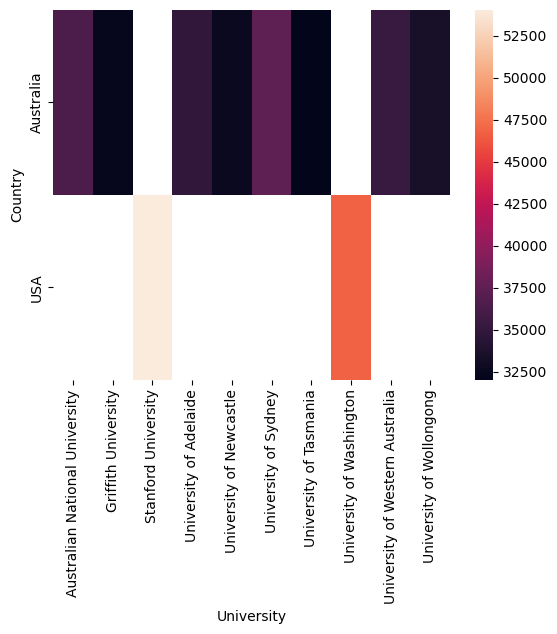

In [351]:
sns.heatmap(data)

In [352]:
#fearure engineering 


In [353]:
df['Total_Cost']=df['Tuition_USD']+df['Rent_USD']

In [354]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate,Total_Cost
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.500000,2200,160,1500,1.00,57600
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.800003,1800,485,800,0.79,43000
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.500000,1600,235,900,1.35,40100
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.199997,1400,450,650,1.52,43400
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.500000,1100,75,550,0.92,1600


In [355]:

#feature section 
#actually 12 features are present 12 are not required i only need 8 no need fot tuition_usd , Rent_USD,Exchange_rate

In [356]:
##Feature selection -->Mention all column names inside the list and that list should be inside the data frame 

In [357]:
df=df[['Country','City','University'	,'Program','Level','Duration_Years','Living_Cost_Index','Visa_Fee_USD','Insurance_USD','Total_Cost']]
df

,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD,Total_Cost
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,83.500000,160,1500,57600
1,UK,London,Imperial College London,Data Science,Master,1.0,75.800003,485,800,43000
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,72.500000,235,900,40100
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,71.199997,450,650,43400
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,70.500000,75,550,1600
...,...,...,...,...,...,...,...,...,...,...
902,France,Strasbourg,University of Strasbourg,Data Analytics,Master,2.0,70.199997,99,850,5000
903,Malaysia,Nilai,USIM,Computer Science,Bachelor,3.0,50.500000,120,400,7200
904,Saudi Arabia,Al-Ahsa,King Faisal University,Information Systems,Master,2.0,64.199997,200,800,4800
905,USA,Seattle,University of Washington,Software Development,PhD,5.0,77.800003,160,1500,52000


# Encoder
## 1.label Encoder
## 2.Ordinal Encoder
## 3.One Hot Encoder

In [358]:
#converting into categories to numbetr 
#by using sklearn 

In [359]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler

In [360]:
label=LabelEncoder()


In [361]:
label.fit_transform(df['Country'])
#for each specific category there is specific value


array([66, 65,  9,  2, 22, 34, 41, 53, 21, 59, 58, 15, 10, 56, 31, 56, 42,
        3,  6, 66, 66, 66, 65,  9, 25, 48, 32, 60, 14, 66, 66, 65, 65, 22,
       59, 41, 53,  9,  2, 58, 66, 66,  9, 65, 28, 15, 47, 31, 56, 38, 66,
       65,  9,  2, 22, 57, 33, 41, 20, 44, 34, 34, 34, 34, 34, 34, 34, 34,
       34, 34, 34,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2, 22, 22, 22, 22,
       22, 22, 22, 22, 22, 22, 66, 66, 66, 66, 66, 66, 66, 66, 66, 66, 65,
       65, 65, 65, 65, 65, 65, 65, 65, 65,  9,  9,  9,  9,  9,  9,  9,  9,
        9,  9, 66, 66,  9,  7, 63, 50, 39, 24, 61, 64, 66, 66, 10, 55, 18,
        1, 29, 51, 43, 70, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 53, 53,
       53, 53, 53, 53, 53, 53, 53, 53, 21, 21, 21, 21, 21, 21, 21, 21, 21,
       21, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 15, 15, 15, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56,
       56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 66, 66, 66, 66, 66, 66, 66,
       66, 66, 66, 66, 66

In [362]:
df['City']=label.fit_transform(df['City'])
df

/var/folders/db/9bfsq9b95f30v8kby7jkyt7m0000gn/T/ipykernel_39584/821335342.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['City']=label.fit_transform(df['City'])


,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD,Total_Cost
0,USA,84,Harvard University,Computer Science,Master,2.0,83.500000,160,1500,57600
1,UK,283,Imperial College London,Data Science,Master,1.0,75.800003,485,800,43000
2,Canada,503,University of Toronto,Business Analytics,Master,2.0,72.500000,235,900,40100
3,Australia,313,University of Melbourne,Engineering,Master,2.0,71.199997,450,650,43400
4,Germany,330,Technical University of Munich,Mechanical Engineering,Master,2.0,70.500000,75,550,1600
...,...,...,...,...,...,...,...,...,...,...
902,France,469,University of Strasbourg,Data Analytics,Master,2.0,70.199997,99,850,5000
903,Malaysia,344,USIM,Computer Science,Bachelor,3.0,50.500000,120,400,7200
904,Saudi Arabia,12,King Faisal University,Information Systems,Master,2.0,64.199997,200,800,4800
905,USA,441,University of Washington,Software Development,PhD,5.0,77.800003,160,1500,52000


In [363]:
df['University']=label.fit_transform(df['University'])
df['Country']=label.fit_transform(df['Country'])
df['City']=label.fit_transform(df['City'])
df['Level']=label.fit_transform(df['Level'])
df['Program']=label.fit_transform(df['Program'])
#converted all categorical columns to numbers 

/var/folders/db/9bfsq9b95f30v8kby7jkyt7m0000gn/T/ipykernel_39584/2508339253.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['University']=label.fit_transform(df['University'])
/var/folders/db/9bfsq9b95f30v8kby7jkyt7m0000gn/T/ipykernel_39584/2508339253.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Country']=label.fit_transform(df['Country'])
/var/folders/db/9bfsq9b95f30v8kby7jkyt7m0000gn/T/ipykernel_39584/2508339253.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

In [364]:
df

,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD,Total_Cost
0,66,84,101,17,1,2.0,83.500000,160,1500,57600
1,65,283,128,27,1,1.0,75.800003,485,800,43000
2,9,503,572,9,1,2.0,72.500000,235,900,40100
3,2,313,495,44,1,2.0,71.199997,450,650,43400
4,22,330,307,66,1,2.0,70.500000,75,550,1600
...,...,...,...,...,...,...,...,...,...,...
902,21,469,556,25,1,2.0,70.199997,99,850,5000
903,38,344,345,17,0,3.0,50.500000,120,400,7200
904,51,12,154,57,1,2.0,64.199997,200,800,4800
905,66,441,585,84,2,5.0,77.800003,160,1500,52000


In [365]:
#now i need to seperate data for input and ouptut for training and testing 
x=df.iloc[:,:9]
y=df['Total_Cost']
df

,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD,Total_Cost
0,66,84,101,17,1,2.0,83.500000,160,1500,57600
1,65,283,128,27,1,1.0,75.800003,485,800,43000
2,9,503,572,9,1,2.0,72.500000,235,900,40100
3,2,313,495,44,1,2.0,71.199997,450,650,43400
4,22,330,307,66,1,2.0,70.500000,75,550,1600
...,...,...,...,...,...,...,...,...,...,...
902,21,469,556,25,1,2.0,70.199997,99,850,5000
903,38,344,345,17,0,3.0,50.500000,120,400,7200
904,51,12,154,57,1,2.0,64.199997,200,800,4800
905,66,441,585,84,2,5.0,77.800003,160,1500,52000


In [366]:
x

,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD
0,66,84,101,17,1,2.0,83.500000,160,1500
1,65,283,128,27,1,1.0,75.800003,485,800
2,9,503,572,9,1,2.0,72.500000,235,900
3,2,313,495,44,1,2.0,71.199997,450,650
4,22,330,307,66,1,2.0,70.500000,75,550
...,...,...,...,...,...,...,...,...,...
902,21,469,556,25,1,2.0,70.199997,99,850
903,38,344,345,17,0,3.0,50.500000,120,400
904,51,12,154,57,1,2.0,64.199997,200,800
905,66,441,585,84,2,5.0,77.800003,160,1500


In [367]:
y

0      57600
1      43000
2      40100
3      43400
4       1600
       ...  
902     5000
903     7200
904     4800
905    52000
906    34800
Name: Total_Cost, Length: 907, dtype: int32

In [368]:
#feature scale -means scale all columnn values should came in same range 
#can go with normalization 
#can go with standarization

In [369]:
from sklearn.preprocessing import StandardScaler

In [370]:
scaler=StandardScaler()

In [371]:
x=scaler.fit_transform(x)
x

array([[ 1.29937861, -1.18314994, -1.25623694, ...,  1.35689949,
        -0.3585248 ,  2.49821139],
       [ 1.25678296,  0.02539721, -1.10697039, ...,  0.80880168,
         1.90854833,  0.31206552],
       [-1.12857335,  1.3614795 ,  1.3476352 , ...,  0.57390231,
         0.16464592,  0.62437207],
       ...,
       [ 0.66044389, -1.62041323, -0.96323222, ..., -0.01690487,
        -0.07950042,  0.31206552],
       [ 1.29937861,  0.98494722,  1.41950429, ...,  0.9511648 ,
        -0.3585248 ,  2.49821139],
       [ 1.25678296,  0.4140757 ,  1.01593175, ..., -0.23044928,
         1.90854833,  0.31206552]])

In [372]:
from sklearn.model_selection import train_test_split

In [373]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [374]:
x_train.shape

(725, 9)

In [375]:
x_test.shape

(182, 9)

In [376]:
y_train.shape

(725,)

In [377]:
y_test.shape

(182,)

In [378]:
#regression
#1.linear regression
#2.Random forest 
#3.decision tree
#4.lasso regressor
#5.ridge regressor
#6.elastic regressor
#7.xgb Regressor

#8.cat bOOST REGRESSOR
#9.SVR
#10.BAGGING
#11.K NEIGHBOUR REGRESSOR
#STACKING REGRESSOR
#ADABoost regressor

In [379]:
from sklearn.linear_model import LinearRegression


In [380]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [381]:
y_predict=lr.predict(x_test)

In [382]:
from sklearn.metrics import mean_squared_error ,mean_absolute_error,r2_score

In [383]:
mean_absolute_error(y_test,y_predict)

8659.427453507891

In [384]:
mean_squared_error(y_test,y_predict)

130433375.80882217

In [385]:
r2_score(y_test,y_predict)

0.5205374075745224

# ridge

In [386]:
from sklearn.linear_model import Ridge
r=Ridge(alpha=1.0)

In [387]:
r.fit(x_train,y_train)

Ridge()

In [388]:
y_predict=r.predict(x_test)

In [389]:
mean_squared_error(y_test,y_predict)

130307098.50061256

In [390]:
mean_absolute_error(y_test,y_predict)

8659.48485629827

# lasso


In [391]:
from sklearn.linear_model import Lasso

In [392]:
l=Lasso()

In [393]:
l.fit(x_test,y_test)

Lasso()

In [394]:
y_predict=l.predict(x_test)

In [395]:
mean_squared_error(y_test,y_predict)

119873498.28750116

In [396]:
mean_absolute_error(y_test,y_predict)

8644.229711424887

# elastic net

In [397]:
from sklearn.linear_model import ElasticNet

In [398]:
e=ElasticNet(alpha=0.01,l1_ratio=0.5)

In [399]:
e.fit(x_test,y_test)

ElasticNet(alpha=0.01)

In [400]:
y_predict=e.predict(x_test)

In [401]:
mean_squared_error(y_test,y_predict)

119885333.13252656

In [402]:
mean_absolute_error(y_test,y_predict)

8660.12936832935

## Decision tree Regessor

In [403]:
from sklearn.tree import DecisionTreeRegressor
tree=DecisionTreeRegressor(max_depth=5)

In [404]:
tree.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=5)

In [405]:
y_predict=tree.predict(x_test)

In [406]:
mean_absolute_error(y_test,y_predict)

4214.62049327467

# Random Foreset Regressor (Ensemble Learning -->combination of multiple decision tree)

In [407]:
from sklearn.ensemble import RandomForestRegressor

In [408]:
forest=RandomForestRegressor(n_estimators=100)
#n_estimator is nothing but how many algorithms are used 

In [409]:
forest.fit(x_train,y_train)

RandomForestRegressor()

In [410]:
y_predict=forest.predict(x_test)

In [411]:
mean_absolute_error(y_test,y_predict)

2684.149633699634

### ensemble learning --->XGBoost Regressor 
###       ---->AdaBoost Regressor
###       ---->CatBoost Regressor

In [412]:
from sklearn.ensemble import AdaBoostRegressor

In [413]:
ada=AdaBoostRegressor(n_estimators=100)

In [414]:
ada.fit(x_train,y_train)

AdaBoostRegressor(n_estimators=100)

In [415]:
y_predict=forest.predict(x_test)

In [416]:
mean_absolute_error(y_test,y_predict)

2684.149633699634

In [417]:
mean_squared_error(y_test,y_predict)

18368539.789053723

# xgboost

In [418]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [419]:
#from xgboost import XGBRegressor

In [420]:
#xg=XGBRegressor(n_estimator=100)

#xg.fit(x_train,y_train)

In [421]:
#y_predict=xg.predict(x_test)

In [422]:
#catboost

In [423]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [424]:
#from catboost import CatBoostRegression
#cat=CatBoostRegression(n_estimators=100)

### kneighbors regression -neighbour data point

In [425]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=5)

In [426]:
knn.fit(x_train,y_train)

KNeighborsRegressor()

In [427]:
y_predict=knn.predict(x_test)

In [428]:
mean_absolute_error(y_test,y_predict)

5825.32967032967

In [429]:
mean_squared_error(y_test,y_predict)

71982015.01098901

# svr

In [430]:
from sklearn.svm import SVR
svr=SVR(kernel='rbf')


In [431]:
svr.fit(x_train,y_train)

SVR()

In [432]:
y_predict=svr.predict(x_test)

In [433]:
mean_absolute_error(y_test,y_predict)

14308.751937260657

In [434]:
mean_squared_error(y_test,y_predict)

371095332.10266525

# Bagging Regressor -->Ensemble Learning

In [435]:
from sklearn.ensemble import BaggingRegressor

In [436]:
bg=BaggingRegressor(n_estimators=100)

In [437]:
bg.fit(x_train,y_train)

BaggingRegressor(n_estimators=100)

In [438]:
mean_squared_error(y_test,y_predict)

371095332.10266525

# Stacking Regressor -->Ensemble Learning -->Combination of Multiple Models of our own choice 

In [440]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import BaggingRegressor

In [448]:
estimator=[('rf',RandomForestRegressor()),('br',BaggingRegressor())]

In [453]:
stack=StackingRegressor(estimators=estimator,final_estimator=DecisionTreeRegressor())

In [455]:
stack.fit(x_train,y_train)

StackingRegressor(estimators=[('rf', RandomForestRegressor()),
                              ('br', BaggingRegressor())],
                  final_estimator=DecisionTreeRegressor())

In [456]:
y_predict=stack.predict(x_test)

In [457]:
mean_absolute_error(y_test,y_predict)

3966.4285714285716

# Logistic Regression
# Decision tree classifier
# random forest classifier 
# catboost classifier
# k neighbour classifier
# sv classifier
# bernouli naive bayes
# multinomial naive bayes
# bagging classifier